In [14]:
import numpy as np
import pandas as pd
dir_path = "(input the directory path)"
#Set latitude
lon1, lon2= 60, 150
df1 = pd.read_csv(dir_path + "residual_train_lon"+str(lon1)+"-"+str(lon2)+".csv")
df2 = pd.read_csv(dir_path + "residual_test_lon"+str(lon1)+"-"+str(lon2)+".csv")


In [15]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ---------- Setting ----------
base_columns = ["Time", "DOY", "Year", "Count","Xray","Elec","Prot","Mag","SYM-H"]
delay_targets_hours = {
    "Xray": list(range(1, 49, 1)),  # 24h〜48h
    "Elec": list(range(1, 13, 1)),   # 6h〜23h
    "Prot": list(range(1, 13, 1)),
    "Mag": list(range(1, 13, 1)),
    "SYM-H": list(range(1, 13, 1))
}
# ---------- Create dataframe with delay features----------
def create_feature_set(df, include_delay=False):
    df_selected = df[base_columns].copy()
    
    if include_delay:
        delay_cols = []
        for var, hours in delay_targets_hours.items():
            for h in hours:
                col_name = f"{var}_t-{h}h"
                if col_name in df.columns:
                    delay_cols.append(col_name)
                else:
                    df[col_name] = np.nan
                    delay_cols.append(col_name)
        df_selected = pd.concat([df_selected, df[delay_cols]], axis=1)
    
    return df_selected

df_train = create_feature_set(df1, include_delay=True)
df_test = create_feature_set(df2, include_delay=True)

# ---------- Set the target of log conversion ----------
log_targets = ['Elec', 'Prot']
log2_targets = ['Xray']
log_cols = [f"{var}_t-{h}h" for var in log_targets for h in delay_targets_hours[var]]
log2_cols = [f"{var}_t-{h}h" for var in log2_targets for h in delay_targets_hours[var]]

# ---------- Exclude column ----------
exclude_cols = ["Time", "DOY", "Year", "Count"]

#Set the target of standariztaion
target_cols1 = [col for col in df_train.columns if col not in exclude_cols]
target_cols2 = [col for col in df_test.columns if col not in exclude_cols]

# ---------- log conversion ----------
for col in log_cols:
    if col in df_train.columns:
        df_train[col] = np.log1p(df_train[col].clip(upper=1e6))
    if col in df_test.columns:
        df_test[col] = np.log1p(df_test[col].clip(upper=1e6))

for col in log2_cols: #X-ray
    if col in df_train.columns:
        df_train[col] = np.log(df_train[col]+1e-9) #log(x+1e-9)
    if col in df_test.columns:
        df_test[col] = np.log(df_test[col]+1e-9)

# ---------- Standariztaion----------
scaler = StandardScaler()
#Only linear regression
df_train[target_cols1] = scaler.fit_transform(df_train[target_cols1])
df_test[target_cols2] = scaler.transform(df_test[target_cols2])

print(df_train.head())
print(df_test.head())

                  Time         DOY  Year     Count      Xray      Elec  \
0  2013-11-19 01:49:42  323.076181  2013 -4.611641 -0.055884 -0.595363   
1  2013-11-19 01:50:42  323.076875  2013 -0.671638 -0.059441 -0.595057   
2  2013-11-19 01:51:42  323.077569  2013 -1.729363 -0.063271 -0.594418   
3  2013-11-19 01:52:42  323.078264  2013  0.214637 -0.067752 -0.593779   
4  2013-11-19 01:53:42  323.078958  2013 -1.839119 -0.071016 -0.593140   

       Prot       Mag     SYM-H  Xray_t-1h  ...  SYM-H_t-3h  SYM-H_t-4h  \
0 -0.292673  0.098847  0.989211   1.187492  ...    0.870232    0.856760   
1 -0.292579  0.100410  0.989211   1.155562  ...    0.870232    0.856760   
2 -0.292409  0.101239  0.989211   1.126761  ...    0.870232    0.856760   
3 -0.292239  0.101151  1.009772   1.101591  ...    0.870232    0.856760   
4 -0.292069  0.100564  1.018576   1.073593  ...    0.870232    0.835508   

   SYM-H_t-5h  SYM-H_t-6h  SYM-H_t-7h  SYM-H_t-8h  SYM-H_t-9h  SYM-H_t-10h  \
0    0.888709    0.858936 

In [16]:
import numpy as np
import pandas as pd

df_testA = df_test.copy()

#  Time ==> datetime 
df_testA['Time'] = pd.to_datetime(df_testA['Time'], errors='coerce', utc=True)
df_testA['Time'] = df_testA['Time'].dt.tz_convert('UTC').dt.tz_localize(None)


sdir = "/media/user/Data/Timeline/Data_table/"
pt = pd.read_csv(sdir+'peak_times.csv', parse_dates=['Time'], dayfirst=False)
pt['Time'] = pd.to_datetime(pt['Time'], errors='coerce', utc=True)
pt['Time'] = pt['Time'].dt.tz_convert('UTC').dt.tz_localize(None)

# drop NaT
pt = pt.dropna(subset=['Time']).drop_duplicates().sort_values('Time').reset_index(drop=True)

# Create ±3 days window
win = pd.DataFrame({
    'start': pt['Time'] - pd.Timedelta(days=3),
    'end'  : pt['Time'] + pd.Timedelta(days=3),
}).sort_values('start').reset_index(drop=True)

# Marge the overlaped periods
merged = []
for s, e in zip(win['start'], win['end']):
    if not merged or s > merged[-1][1]:
        merged.append([s, e])
    else:
        merged[-1][1] = max(merged[-1][1], e)

if len(merged) == 0:
    df_testA['is_anomaly_window'] = 0
else:
    win_merged = pd.DataFrame(merged, columns=['start', 'end'])

    # Convert all values to datetime64[ns] before using searchsorted
    starts = win_merged['start'].to_numpy(dtype='datetime64[ns]')
    ends   = win_merged['end'].to_numpy(dtype='datetime64[ns]')
    t      = df_testA['Time'].to_numpy(dtype='datetime64[ns]')

    # Searchsorted assumes that the array is sorted in ascending order
    sort_idx = np.argsort(starts)
    starts = starts[sort_idx]
    ends   = ends[sort_idx]

    idx = np.searchsorted(starts, t, side='right') - 1
    in_range = (idx >= 0) & (t <= ends[idx])

    df_testA['is_anomaly_window'] = in_range.astype(int)

df_testA = df_testA.drop(columns=['is_anomaly_window'])

In [17]:
from pycaret.regression import *
from pycaret.regression import get_config, pull
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# PyCaret setup
reg1 = setup(data=df_train, target='Count',ignore_features=["Time","DOY","Year","LT"],
             fold_strategy="timeseries",fold=5,data_split_shuffle=False,fold_shuffle=False,session_id=123)

,Description,Value
0,Session id,123
1,Target,Count
2,Target type,Regression
3,Original data shape,"(8666, 105)"
4,Transformed data shape,"(8666, 102)"
5,Transformed train set shape,"(6066, 102)"
6,Transformed test set shape,"(2600, 102)"
7,Ignore features,4
8,Numeric features,101
9,Preprocess,True


In [20]:
# Create model and prediction
model = create_model("ridge") 
#model = create_model("en") 
#model = create_model("lasso") 
model2 = tune_model(model, optimize="MAE")
test_pred_ri = predict_model(model2, data=df_test)

model = create_model("rf") 
model2 = tune_model(model, optimize="MAE")
test_pred_rf = predict_model(model2, data=df_test)

#model = create_model("lightgbm") 
model = create_model("xgboost") 
model2 = tune_model(model, optimize="MAE")
test_pred_lg = predict_model(model2, data=df_test)

model = create_model("mlp") 
model2 = tune_model(model, optimize="MAE")
test_pred_ml = predict_model(model2, data=df_test)

model = create_model("knn") 
model2 = tune_model(model, optimize="MAE")
test_pred_kn = predict_model(model2, data=df_test)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.6672,155.6360,12.4754,-5.5589,1.3189,15.6771
1,6.4208,61.7722,7.8595,-3.6895,1.0614,13.1202
2,9.0166,240.7243,15.5153,-12.6486,1.1874,16.3624
3,4.5084,38.0682,6.1699,-1.0739,0.8581,10.4777
4,4.4934,49.3134,7.0224,-1.3298,0.9285,5.5346
Mean,6.8213,109.1028,9.8085,-4.8601,1.0709,12.2344
Std,2.1839,77.9108,3.5911,4.2265,0.1678,3.9408


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.0816,86.6909,9.3108,-2.6534,1.1156,11.6516
1,4.8290,35.2316,5.9356,-1.6746,0.9267,9.1894
2,5.8945,66.6679,8.1650,-2.7799,0.9872,9.5074
3,4.0741,31.7389,5.6337,-0.7291,0.8092,9.3505
4,4.4406,47.9531,6.9248,-1.2656,0.9269,5.4591
Mean,5.2640,53.6565,7.1940,-1.8205,0.9531,9.0316
Std,1.0940,20.5570,1.3794,0.7918,0.0997,1.9990


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Ridge Regression,4.5637,33.3735,5.7770,-1.1065,0.9089,3.7994


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,16.4391,343.9643,18.5463,-13.4956,1.7170,36.7931
1,5.5965,56.0059,7.4837,-3.2517,0.9520,12.9155
2,11.1306,213.4620,14.6103,-11.1028,1.2980,17.5096
3,5.5437,115.6108,10.7522,-5.2984,1.0679,39.0919
4,6.1937,74.3508,8.6227,-2.5127,1.0617,11.4387
Mean,8.9807,160.6788,12.0031,-7.1323,1.2193,23.5498
Std,4.2728,106.6018,4.0750,4.3822,0.2732,11.9431


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,MLP Regressor,6.0369,55.5006,7.4499,-2.5032,0.8144,7.3164


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.2610,41.4940,6.4416,-0.7487,0.9638,4.4422
1,4.0844,31.3561,5.5997,-1.3804,0.9319,5.5522
2,3.2709,20.4169,4.5185,-0.1576,0.7816,3.0617
3,3.2414,20.8870,4.5702,-0.1379,0.8324,4.1648
4,4.3115,40.5773,6.3700,-0.9171,0.9387,4.5673
Mean,3.8338,30.9462,5.5000,-0.6683,0.8897,4.3576
Std,0.4778,9.1240,0.8344,0.4728,0.0702,0.7993


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5612,26.5184,5.1496,-0.1176,1.0119,3.2493
1,3.2259,16.1506,4.0188,-0.2261,0.8865,4.4385
2,3.1111,18.4068,4.2903,-0.0436,0.9729,2.4757
3,3.0465,19.5422,4.4207,-0.0646,0.8932,2.6528
4,3.5512,27.7539,5.2682,-0.3112,0.9372,3.1755
Mean,3.2992,21.6744,4.6295,-0.1526,0.9404,3.1983
Std,0.2176,4.6078,0.4920,0.1014,0.0476,0.6872


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,K Neighbors Regressor,3.4779,20.4658,4.5239,-0.2918,1.1619,1.7263


In [ ]:
#Model save
save_model(lr_model, 'my_regression_model')

In [1]:
offset = np.array([80,130,180,230,280])
#Only use the data in 2017
year = 2017
mask_year = df_test["Year"] == year
df_test_year = df_test[mask_year].reset_index(drop=True)
time = df_test_year["DOY"] 

dfm_year = test_pred_ri[mask_year].reset_index(drop=True) #Ridge
y_true = dfm_year["Count"]

# Plot
plt.rcParams["font.size"] = 15
plt.figure(figsize=(6, 4.8))
plt.scatter(time, y_true, label='Observation', color='blue', s=2)

# Prediction result
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[0], label='Ridge',color='red', linewidth=1)

#Other model
dfm_year = test_pred_rf[mask_year].reset_index(drop=True) #random forest
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[1], label='Random forest',color='green', linewidth=1)

dfm_year = test_pred_lg[mask_year].reset_index(drop=True)
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[2], label='LightGBM',color='purple', linewidth=1)

dfm_year = test_pred_ml[mask_year].reset_index(drop=True)
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[3], label='MLP', linewidth=1)

dfm_year = test_pred_kn[mask_year].reset_index(drop=True)
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[4], label='K-nn', linewidth=1)

# set axis rabel etc.
plt.xlabel('Day of Year')
plt.ylabel('Count rate (/min)')
#plt.xlim([235,246])
#plt.xlim([246,256])
#plt.xlim([251,252])
#plt.xlim([0,365])
#plt.ylim([-20,70])
plt.ylim([-20,300])
#plt.legend(fontsize=12)
plt.title(f'{year}')
plt.tight_layout()
plt.savefig("enhancement event 2017.png",dpi=600)
plt.show()


NameError: name 'np' is not defined

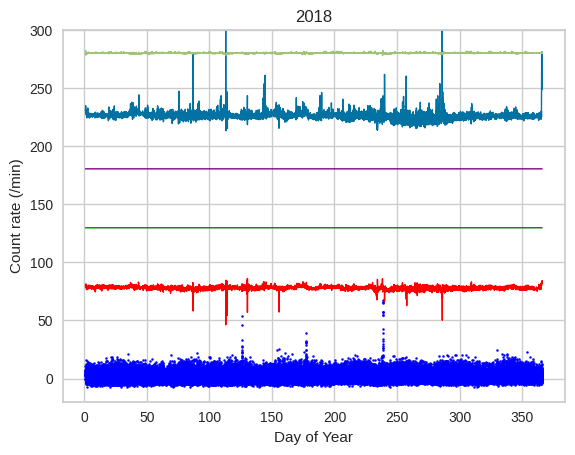

In [29]:
offset = np.array([80,130,180,230,280])
#Only use the data in 2018
year = 2018
mask_year = df_test["Year"] == year
df_test_year = df_test[mask_year].reset_index(drop=True)
time = df_test_year["DOY"]  

dfm_year = test_pred_ri[mask_year].reset_index(drop=True) #Ridge
y_true = dfm_year["Count"]


plt.rcParams["font.size"] = 15
plt.figure(figsize=(6, 4.8))
plt.scatter(time, y_true, label='Observation', color='blue', s=2)

y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[0], label='Ridge', color='red', linewidth=1)

#Other model
dfm_year = test_pred_rf[mask_year].reset_index(drop=True) #random forest
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[1], label='Random forest',color='green', linewidth=1)

dfm_year = test_pred_lg[mask_year].reset_index(drop=True)
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[2], label='LightGBM',color='purple', linewidth=1)

dfm_year = test_pred_ml[mask_year].reset_index(drop=True)
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[3], label='MLP', linewidth=1)

dfm_year = test_pred_kn[mask_year].reset_index(drop=True)
y_pred = dfm_year["prediction_label"]
plt.plot(time, y_pred+offset[4], label='K-nn', linewidth=1)


plt.xlabel('Day of Year')
plt.ylabel('Count rate (/min)')
#plt.xlim([235,246])
#plt.xlim([246,256])
#plt.xlim([251,252])
#plt.xlim([85,95])
plt.ylim([-20,300])
plt.title(f'{year}')

#plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("enhancement event 2018.png",dpi=600)
plt.show()